In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "Dolson30"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
   # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Comparative Experiments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Comparative Experiments


# STAT 7220 - Midterm Exam
## David Olson

**DUE: October 28, 2025**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Counter-Strike) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

 - The Objective of this experiment is to determine if there is a statistically significant difference in the percieved comfort level of video game controller grips based on the material type used for the grip.

**Question 2.** Specify the outcome variable

 - The outcome variable (dependent variable) is the percieved comfort level rating given by the professional gamers. It is a quantitative variable with a 1 to 10 rating possible.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

- The independent variable is the material type used for the controller grips. Plastic, rubber, silicone, and metal being the options. (Side note, I sure hope metal "loses"... who would play CS with a metal grip!?).

- Some lurking variables include
    - Hand size and shape of the gamers, this could affect the feel of one material vs others.
    - Playing style or grip style. Some gamers hold controllers more tightly than others, and some gamers hold controllers differently than others.
    - Sweatiness. Despite the cliche, not all gamers sweat the same. Sweatier hands may impact the feel of smoother materials (metal or smooth plastic) more than the more textured materials.
    - Ambient Temperature in each gamers testing rooms. This falls under the above category, but the environment could impact the feel of some materials in cold/hot rooms, even outside of sweatiness.
    - Total hours played? Each gamer is given a month to use their controller, but it's possible that these gamers play a vastly different amount of the game in a given month. One could play for an hour a day, another for 8. This could impact wear and tear or general time spent getting comfortable with the controller.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

- CRD is appropriate because one single factor is being studied. Being focused solely on one independent variable, the material type, allows for a very simple and fundimental experimental design.

- Randomness of assignment is assumed here. The assumption is that the 40 total trials are independent and that differences between the 40 gamers are balanced across the four material groups due to randomization.

- Homogeneity of Experimental Units. This design assumes that the users are all professional gamers, they all play the same game, and they all use the controllers for the same duration. This would help us "ensure" that observed differences are due to the material type and not other pre-existing differences between the groups.

**Question 5.** State the null and alternative hypotheses for this experiment.

- Null Hypothesis: There is no statistically significant difference in the mean perceived comfort level among the four material types (plastic, rubber, silicone, and metal).

- Alternative Hypothesis: At least one of the mean perceived comfort levels is statistically different from the others.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

--- Summary Statistics by Material ---
          count  mean       std  min  max
Material                                 
Silicone     10  8.32  0.689283  7.3  9.2
Rubber       10  6.57  0.860297  5.3  8.0
Plastic      10  5.89  0.448330  5.2  6.8
Metal        10  4.95  0.538000  4.2  5.6


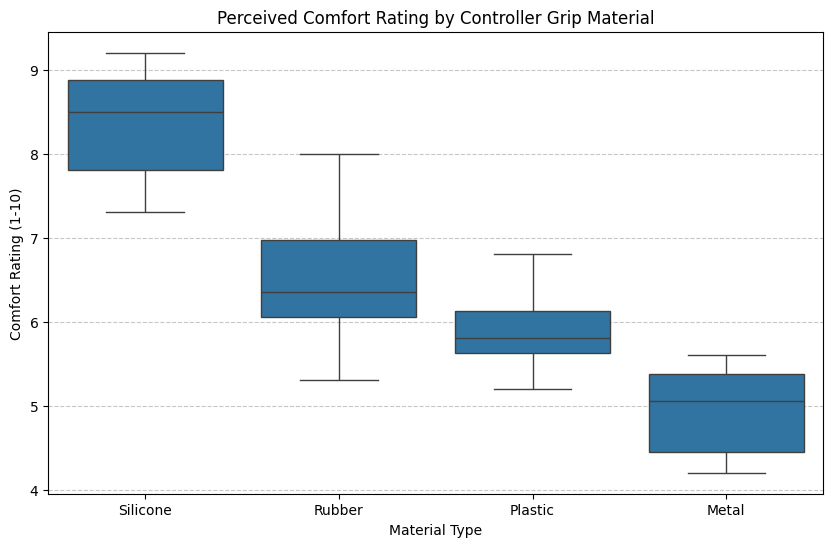

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/Video Game Controllers.xlsx")

summary_stats = df.groupby('Material')['Comfort'].agg(['count', 'mean', 'std', 'min', 'max']).sort_values(by='mean', ascending=False)

print("--- Summary Statistics by Material ---")
print(summary_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Material', y='Comfort', data=df, order=summary_stats.index)
plt.title('Perceived Comfort Rating by Controller Grip Material')
plt.xlabel('Material Type')
plt.ylabel('Comfort Rating (1-10)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- There are large differences between the sample means and there is not much overlap in the box plot, so that would suggest that the material type has a substantial impact on comfort while gaming.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?


Test Statistic (W): 0.9885
P-value: 0.9509


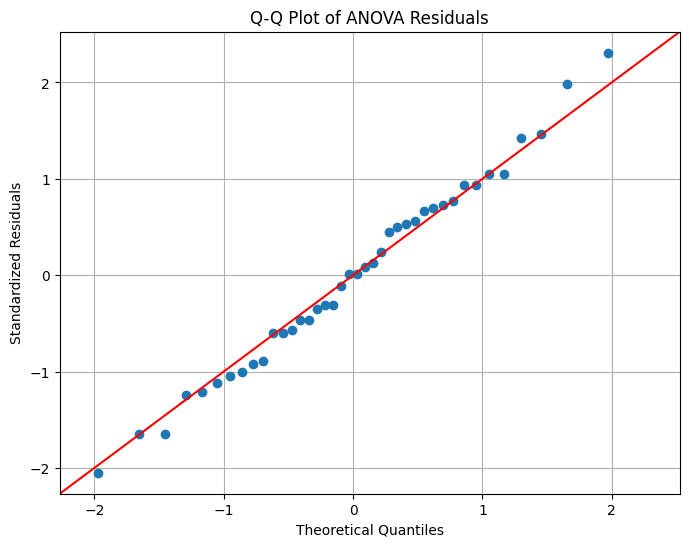

In [17]:
model = ols('Comfort ~ C(Material)', data=df).fit()
residuals = model.resid
shapiro_test = shapiro(residuals)
print(f"Test Statistic (W): {shapiro_test.statistic:.4f}")
print(f"P-value: {shapiro_test.pvalue:.4f}")

plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of ANOVA Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.grid(True)

- The results of both the Shapiro-Wilk test (high P-values) and the Q-Q plot ( a nice linear pattern) support the assumption of normality. This allows us to proceed with next steps in testing.

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

Test Statistic (F): 2.0100
P-value: 0.1299


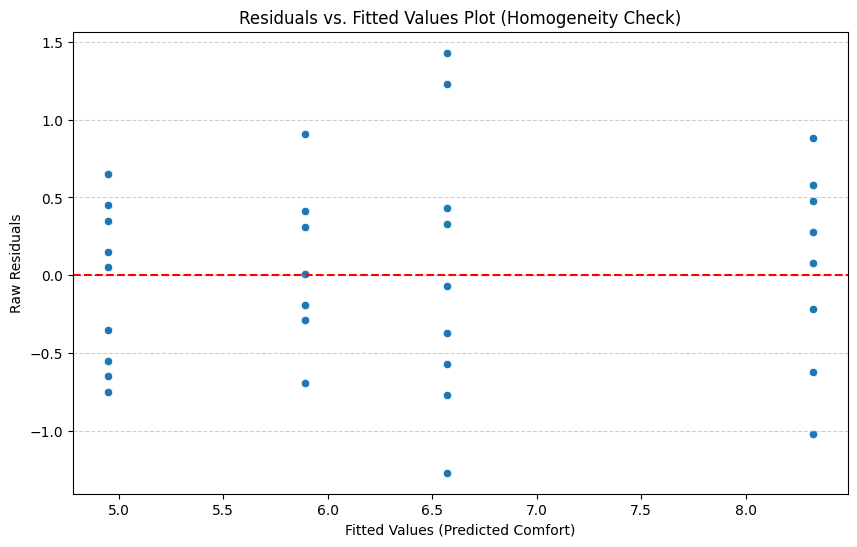

In [19]:
import pandas as pd
from statsmodels.formula.api import ols
from scipy.stats import levene
import matplotlib.pyplot as plt
import seaborn as sns

model = ols('Comfort ~ C(Material)', data=df).fit()

plastic = df[df['Material'] == 'Plastic']['Comfort']
rubber = df[df['Material'] == 'Rubber']['Comfort']
silicone = df[df['Material'] == 'Silicone']['Comfort']
metal = df[df['Material'] == 'Metal']['Comfort']

levene_test = levene(plastic, rubber, silicone, metal, center='mean')

print(f"Test Statistic (F): {levene_test.statistic:.4f}")
print(f"P-value: {levene_test.pvalue:.4f}")

fitted_values = model.fittedvalues
raw_residuals = model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=raw_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values Plot (Homogeneity Check)')
plt.xlabel('Fitted Values (Predicted Comfort)')
plt.ylabel('Raw Residuals')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

- A p-value of 0.1299 in Levene's test tells us that we fail to reject the null hypothesis (this is good in this case!) and that there are no statistically significant pieces of evidence to suggest that the variances in scores differ across material types. The fitted values polot shows us a relatively uniform scattering around zero.

- Both of these results support the assumption of homogeneity of variance.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

In [20]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Comfort ~ C(Material)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
f_statistic = anova_table.loc['C(Material)', 'F']
p_value = anova_table.loc['C(Material)', 'PR(>F)']
print(f"\nF-statistic for Material: {f_statistic:.4f}")
print(f"P-value for Material: {p_value:.4f}")

               sum_sq    df          F        PR(>F)
C(Material)  60.73675   3.0  47.478405  1.348029e-12
Residual     15.35100  36.0        NaN           NaN

F-statistic for Material: 47.4784
P-value for Material: 0.0000


- Since the p-value of 0.0000 is much less than our typical significance level of 0.05, we reject the null hypothesis. This means there is sufficient evidence to conclude that at least one of the true mean comfort levels is significantly different from the others.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

In [21]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_results = pairwise_tukeyhsd(endog=df['Comfort'], groups=df['Material'], alpha=0.05)
print(tukey_results)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.94 0.0139  0.1535 1.7265   True
  Metal   Rubber     1.62    0.0  0.8335 2.4065   True
  Metal Silicone     3.37    0.0  2.5835 4.1565   True
Plastic   Rubber     0.68 0.1104 -0.1065 1.4665  False
Plastic Silicone     2.43    0.0  1.6435 3.2165   True
 Rubber Silicone     1.75    0.0  0.9635 2.5365   True
------------------------------------------------------


- This tells us that silicone is significantly more comfortable than all other materials. Rubber and plastic are not  that different from one another in terms of comfort. Metal is significantly less comfortable than all other materials (I KNEW IT!!).

- The results would suggest Silicone > Rubber / Plastic > Metal

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses.

- The objective of our experiment was to determine if material type used for controller grips significantly impacted the perceived comfort level rated by professional gamers.

- The results of the one way ANOVA showed a highly statistically significant effect of material type on comfort with a p-value < 0.001, leading to a strong rejection of the null hypothesis and confirmation that material choice is critical to comfort.

- Tukey's HSD post-hoc further told us that silicone grips were by far the most comfortable grips with the highest mean percieved comfort (Xbar = 8.32) and ranked higher than all other materials. Rubber and plastic were up next (Xbar = 6.57 and Xbar = 5.89 respectively), closely significant to one another. Metal provided by far the least comfort with an Xbar of 4.95.

- I would recommend the manufacturer focus on silicone grips to maximized the comfort for its gamers!

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

- The Objective of this experiment is to determine if a VR class session is more effective than a traditional teaching technique at fostering and preparing attitudes for nursing students eventually dealing with elderly patients. There are some students with prior experience edealing with elderly people, and that is accounted for in the results.

**Question 2.** Specify the outcome variable

- The outcome variable is the quiz score, ranging from 0 to 50. It measures the attitude towards elderly people where closer to 50 is more favorable.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

- The Independent Variable is the Teaching Method.
  - Levels:
     - VR (Class session utilizing the Virtual Reality experience)
     - Traditional Technique (Class session using the conventional teaching method)

- The blocking factor is prior experience working with elderly people.

- Some Lurking variables could be:
  - Existing attitude towards elderly people. Even outside of experience working with them, some student may have an inherent positive or negative feeling towards the elderly.
  - Student's general intelligence. Their ability to absorb the material or take quizzes could impact the outcome.
  - VR Sickness? Some folks just do not take well to VR. That could severely impact the ability to learn in that type of environment.
  - Instructor. The instructor differences between in person and VR could also impact the quality of education the nursing students get.

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

- An RBD is ideal because there is a known factor that is not the primary focus of the study but is potentially influential to the outcome. This allows us to control for the known nuisance factor by dividing the students into blocks first. The main goal is to test the effect of teaching method, by creating blocks the variability of prior experience is removed from experimental factor.

- A CRD would simply place all 40 students into one of the two groups without taking into account experience with working with elderly patients. The experimental error would then, in theory, be artificially inflated. There is a chance that 15 of the 20 experienced students are all placed in the VR group or vice versa. This would certainly impact the scores.

**Question 5.** State the null and alternative hypotheses for this experiment.

- Null Hypothesis: There is no statistically significant difference in the true mean attitude score toward elderly people between the VR teaching method and the Traditional teaching method.

- Alternative Hypothesis: There is a statistically significant difference in the true mean attitude score toward elderly people between the two teaching methods.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?


--- Summary Statistics by Teaching Method (Marginal Means) ---
             count   mean       std
Method                             
VR              20  40.75  6.896796
Traditional     20  31.30  5.676359

--- Summary Statistics by Prior Experience (Marginal Means) ---
                     count   mean       std
Experience                                 
Prior Experience        20  36.15  8.725492
No Prior Experience     20  35.90  7.114847

--- Summary Statistics by Group (Cell Means) ---
                                 count  mean       std
Method      Experience                                
VR          Prior Experience        10  41.2  7.857056
            No Prior Experience     10  40.3  6.183311
Traditional No Prior Experience     10  31.5  5.060742
            Prior Experience        10  31.1  6.505553


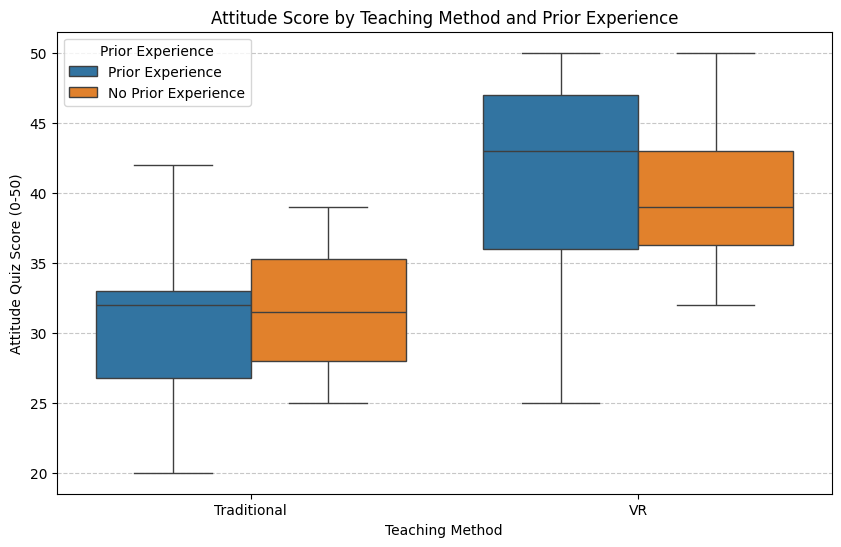

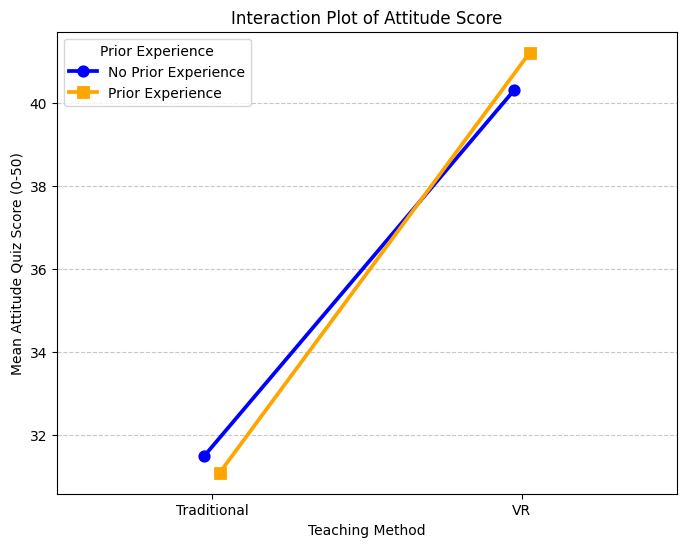

In [29]:
import pandas as pd

df_nursing = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/Nursing VR Study.xlsx")


method_stats = df_nursing.groupby('Method')['Score'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
print("\n--- Summary Statistics by Teaching Method (Marginal Means) ---")
print(method_stats)


experience_stats = df_nursing.groupby('Experience')['Score'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
print("\n--- Summary Statistics by Prior Experience (Marginal Means) ---")
print(experience_stats)


cell_stats = df_nursing.groupby(['Method', 'Experience'])['Score'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
print("\n--- Summary Statistics by Group (Cell Means) ---")
print(cell_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Method', y='Score', hue='Experience', data=df_nursing,
            order=df_nursing['Method'].unique())
plt.title('Attitude Score by Teaching Method and Prior Experience')
plt.xlabel('Teaching Method')
plt.ylabel('Attitude Quiz Score (0-50)')
plt.legend(title='Prior Experience')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


cell_means = df_nursing.groupby(['Method', 'Experience'])['Score'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.pointplot(data=cell_means, x='Method', y='Score', hue='Experience',
              palette=['blue', 'orange'], dodge=True, errorbar=None, markers=['o', 's'])
plt.title('Interaction Plot of Attitude Score')
plt.xlabel('Teaching Method')
plt.ylabel('Mean Attitude Quiz Score (0-50)')
plt.legend(title='Prior Experience')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- The grouped box plot visually confirms a difference in scoring between traditional and VR. The interaction plot shows 2 nearly parallel lines. The interaction plot wouyld tell us that there is not strong interaction between the teaching method and experience.

- Using summary stats, the marginal mean difference between VR and traditional is about 9.45, that would seem to indicate that VR methods seems to increase favorable attitudes towards patients. Also, the marginal mean blocking factor for prior experience at 0.25 woud suggest that prior experience may not be as impactful as we first thought.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

Test Statistic (W): 0.9735
P-value: 0.4612


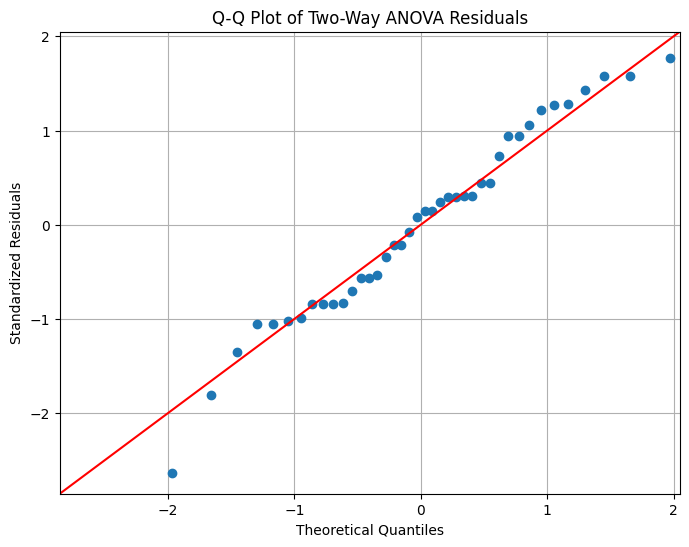

In [30]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import shapiro
import matplotlib.pyplot as plt

model_full = ols('Score ~ C(Method) * C(Experience)', data=df_nursing).fit()
residuals = model_full.resid

shapiro_test = shapiro(residuals)
print(f"Test Statistic (W): {shapiro_test.statistic:.4f}")
print(f"P-value: {shapiro_test.pvalue:.4f}")

plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Two-Way ANOVA Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.grid(True)
plt.show()

- The results of both the shapiro wilk and the Q-Q plot support the assumption of normality. The p-value of 0.4612 means we fail to reject the null hypothesis of the test indicating a normal distribution. The Q-Q plot shows a nice plot of the residuals along a 45 degree line, an expected pattern.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

Test Statistic (F): 0.7007
P-value: 0.5578


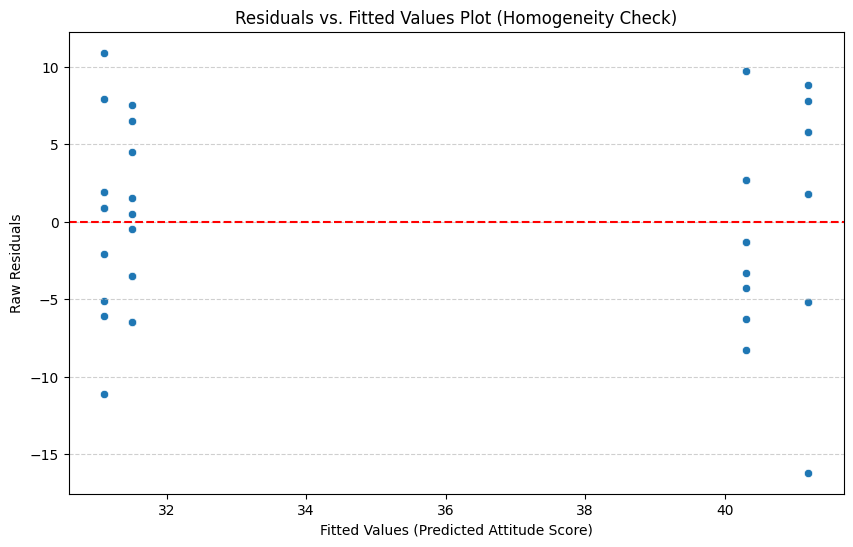

In [31]:
group_vr_exp = df_nursing[(df_nursing['Method'] == 'VR') & (df_nursing['Experience'] == 'Prior Experience')]['Score']
group_vr_noexp = df_nursing[(df_nursing['Method'] == 'VR') & (df_nursing['Experience'] == 'No Prior Experience')]['Score']
group_trad_exp = df_nursing[(df_nursing['Method'] == 'Traditional') & (df_nursing['Experience'] == 'Prior Experience')]['Score']
group_trad_noexp = df_nursing[(df_nursing['Method'] == 'Traditional') & (df_nursing['Experience'] == 'No Prior Experience')]['Score']

levene_test = levene(group_vr_exp, group_vr_noexp, group_trad_exp, group_trad_noexp, center='mean')
print(f"Test Statistic (F): {levene_test.statistic:.4f}")
print(f"P-value: {levene_test.pvalue:.4f}")

fitted_values = model_full.fittedvalues
raw_residuals = model_full.resid
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=raw_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values Plot (Homogeneity Check)')
plt.xlabel('Fitted Values (Predicted Attitude Score)')
plt.ylabel('Raw Residuals')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

- The null hypothesis for Levene's is that all 4 group variances are equal. The p-value of 0.5578 would indicate that we fail to reject the null hypothesis and there is no evidence that the variances are unequal.

- The fitted plot shows residsuals scatteres across the 4 fitted values. The vertical spread around y=0 seems roughly similar. There is no clear pattern for increasing spread which suggests homogeneity of variance.

- Both tests support the assumption of homogeneity.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

In [33]:
model_rbd = ols('Score ~ C(Method) + C(Experience)', data=df_nursing).fit()
anova_table = sm.stats.anova_lm(model_rbd, typ=2)
print("--- Two-Way ANOVA Table (RBD Model) ---")
print(anova_table)
f_statistic = anova_table.loc['C(Method)', 'F']
p_value = anova_table.loc['C(Method)', 'PR(>F)']
print(f"\nF-statistic for Method (Treatment): {f_statistic:.4f}")
print(f"P-value for Method (Treatment): {p_value:.4f}")

--- Two-Way ANOVA Table (RBD Model) ---
                 sum_sq    df          F    PR(>F)
C(Method)       893.025   1.0  21.805174  0.000039
C(Experience)     0.625   1.0   0.015261  0.902353
Residual       1515.325  37.0        NaN       NaN

F-statistic for Method (Treatment): 21.8052
P-value for Method (Treatment): 0.0000


- The f-statistic of 21.8052 is large indicating that the attitude scores between the VR and traditional teaching groups is much greater than the variation within the groups. A P-value of 0.00004 is extremely small. This would lead us to reject the null hypothesis. It confirms there is a statistically significant difference in the attitude score between teaching methods.
- The p-value for the blocking factor is high, which means we fail to reject the null hypothesis and conclude that the blocking factor did not have a significant effect on the attitude score.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

- I am not sure Tukey's HSD Post-hoc test is necessary here. We are only testing VR vs Standard so there is only one possible comparison. The ANOVA F-test tells us everything we need to know about these two categories.

- That said... I was curious about the teaching method/Experience categories. So Tukey's HSD Post-Hoc for those...

In [34]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_nursing['Group'] = df_nursing['Method'].astype(str) + '_' + \
                      df_nursing['Experience'].astype(str).str.replace(' ', '')
tukey_results_cells = pairwise_tukeyhsd(endog=df_nursing['Score'], groups=df_nursing['Group'], alpha=0.05)

print("--- Tukey's HSD Post-Hoc Test Results (All Four Cells) ---")
print(tukey_results_cells)

--- Tukey's HSD Post-Hoc Test Results (All Four Cells) ---
                      Multiple Comparison of Means - Tukey HSD, FWER=0.05                       
            group1                       group2           meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------------------------
Traditional_NoPriorExperience Traditional_PriorExperience     -0.4  0.999 -8.2034  7.4034  False
Traditional_NoPriorExperience        VR_NoPriorExperience      8.8  0.022  0.9966 16.6034   True
Traditional_NoPriorExperience          VR_PriorExperience      9.7 0.0099  1.8966 17.5034   True
  Traditional_PriorExperience        VR_NoPriorExperience      9.2 0.0155  1.3966 17.0034   True
  Traditional_PriorExperience          VR_PriorExperience     10.1 0.0069  2.2966 17.9034   True
         VR_NoPriorExperience          VR_PriorExperience      0.9 0.9894 -6.9034  8.7034  False
--------------------------------------------------------------------

- Based on the Tukey's HSD post-hoc test results, the differences in attitude scores fall into two clear categories. The most impactful finding is that all comparisons between any VR group and any Traditional group were statistically significant (p < 0.05), confirming that the VR teaching method is superior in fostering favorable attitudes, regardless of whether a student had prior experience or not. Conversely, no significant differences were found within the VR groups (p=0.9894) or within the Traditional groups (p=0.9990), strongly indicating that the student's prior working Experience was not a significant factor

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment.

- The analysis of the nursing student attitude study, conducted as a Randomized Block Design experiment, reveals a clear and statistically significant effect of the teaching method on favorable attitude scores toward the elderly.
  - The Randomized Block Design ANOVA showed that the Teaching Method was the primary source of variability, yielding a highly significant F-statistic (F=21.8052) with a P-value of p=0.0000. This leads to a strong rejection of the null hypothesis.

  - VR Superiority: Post-hoc testing and summary statistics confirm the Virtual Reality (VR) method is significantly more effective than the Traditional method.
    - VR Mean Score: Xbar = 40.75
    - Traditional Mean Score: Xbar = 31.30

  - All pairwise comparisons between VR groups and Traditional groups were statistically significant, demonstrating a robust improvement in attitude score attributed to the VR intervention.
  - The blocking factor, Prior Experience, was found to be statistically insignificant (p=0.9024) and did not meaningfully affect the attitude score.

This experiment provides strong evidence that integrating Virtual Reality into nursing education is a more effective strategy for improving student attitudes toward the elderly than traditional teaching approaches.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

- The CRD usually isn't the best fit for human studies because people are incredibly diverse. A CRD essentially assumes that the experimental units (the participants) are all interchangeable. In reality, factors like age, previous training, motivation, or background can have a huge impact on the outcome. If a CRD is used, human-to-human variability gets lumped into the "error" term, which makes the experiment less able to spot a real effect from the treatment.


**Question 2.** What is the purpose of post-hoc tests?

- The purpose of post-hoc tests is to identify exactly which pairs of means are significantly different following a statistically significant ANOVA F-test. When a factor has three or more levels, the F-test only tells you that at least one pair of means is different. Post-hoc tests run all possible pairwise comparisons ensuring that the overall chance of making a Type I error across all comparisons remains at the set alpha level.

**Question 3.** Explain the difference between RBD and LSD.

- Randomized Block Design (RBD): This controls for one major source of variability, which is your block factor (like controlling for prior experience in the nursing study). You need treatments to be randomly assigned within those blocks.

- Latin Square Design (LSD): This is for when you need to control for two different sources of nuisance variation simultaneously. The catch is that the number of levels for your treatment, your row block, and your column block must all be equal.

**Question 4.** Explain why randomization is important in designing experiments.

- Randomization is essential because it is our best defense against bias. By randomly assigning participants to treatment groups, we ensure that any differences between the groups that existed before the treatment began (like hidden physical differences, slight motivation variations, etc.) are distributed evenly. This makes the groups roughly equivalent at the start, so if we see a difference at the end, we can credibly say it was caused by the treatment and not some lurking variable.

**Question 5.** Explain why replication is important in designing experiments.

- Replication means giving the same treatment to several different experimental units. It's important for a couple of reasons:

    - Estimating Error: It provides us with multiple measurements under the same conditions, which allows us to calculate the variance. We need this error measurement to see if the differences we observe between treatments are actually bigger than what we'd expect from random chance.

    - Boosting Precision: Having more data points gives us a more precise estimate of the true mean response for each treatment, which, in turn, makes the statistical test more powerful.